# Notebook 19 – Mini Challenge (Simple Version)


Dataset - data.csv 

## 1. Understand the problem
"Early" means we can only use a customer's **first few weeks** of behaviour — not their whole history. "Promising" means we must decide, for each new customer, whether they will turn out to be valuable.

## 2. Identify the target
**High-Value (1)** = a customer's **total spend** ends up in the **top 25%** of all new customers. Otherwise **Not High-Value (0)**.

## 3. ML problem type
The target has two categories → **binary classification**. Main metric: **ROC-AUC**, because marketing will likely rank customers rather than use a fixed cut-off.

## 4. Inspect the data

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PowerTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
df = pd.read_csv("data.csv", encoding="ISO-8859-1", dtype={"InvoiceNo": str, "StockCode": str})
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], format="%m/%d/%Y %H:%M")
print(df.shape, "| missing CustomerID:", df.CustomerID.isna().mean().round(2))

(541909, 8) | missing CustomerID: 0.25


## 5. Prepare features

* Keep only real sales (no cancellations, no missing customer ID).
* Keep customers whose **first purchase** was before **10 Sep 2011** (so we can see ~90 days of what they did next).
* Build a few simple features from each customer's **first 30 days**.
* Build the target from their **total spend** (their whole history).

In [3]:
d = df.dropna(subset=["CustomerID"]).drop_duplicates().copy()
d["CustomerID"] = d.CustomerID.astype(int)
sales = d[~d.InvoiceNo.str.startswith("C") & (d.Quantity > 0) & (d.UnitPrice > 0)].copy()
sales["Amount"] = sales.Quantity * sales.UnitPrice
first = sales.groupby("CustomerID").InvoiceDate.min()
new_customers = first[first < "2011-09-10"].index
sub = sales[sales.CustomerID.isin(new_customers)].copy()
sub["day"] = (sub.InvoiceDate - sub.CustomerID.map(first)).dt.days
window = sub[sub.day <= 30]                                    
g = window.groupby("CustomerID")
X = pd.DataFrame({"orders_30d": g.InvoiceNo.nunique(), "spend_30d": g.Amount.sum(),
                  "products_30d": g.StockCode.nunique()}).reindex(new_customers).fillna(0)
lifetime = sub.groupby("CustomerID").Amount.sum()                   
y = (lifetime >= lifetime.quantile(0.75)).astype(int)
print(f"Customers: {len(X)} | High-value: {y.mean():.0%}")
X.head()

Customers: 3370 | High-value: 25%


,orders_30d,spend_30d,products_30d
CustomerID,,,
12346,1,77183.60,1
12347,1,711.79,31
12348,1,892.80,13
12350,1,334.40,17
12352,4,1401.48,26


## 6. Select features
Only 3 simple, easy-to-explain features, so nothing to remove here (no duplicates, all vary).

## 7. Split the data
60% training / 20% validation / 20% test, keeping the 25% high-value rate equal in each (`stratify`).

In [3]:
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=42)
print(f"Train {len(X_train)} | Validation {len(X_val)} | Test {len(X_test)}")

Train 2022 | Validation 674 | Test 674


## 8. Select algorithms

| Model | Why |
|---|---|
| Baseline | Minimum bar to beat |
| Logistic Regression | Simple, fast, easy to explain to marketing |
| Decision Tree | Gives readable "if…then" rules |
| Random Forest | Handles non-linear patterns |

## 9. Train multiple models

In [4]:
models = {
    "Baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": make_pipeline(PowerTransformer(), LogisticRegression(max_iter=1000)),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}
for m in models.values():
    m.fit(X_train, y_train)

## 10. Evaluate models  (on the validation set)

In [5]:
def get_proba(m, X):
    return m.predict_proba(X)[:, 1]
results = {}
for name, m in models.items():
    p, proba = m.predict(X_val), get_proba(m, X_val)
    results[name] = {"Accuracy": accuracy_score(y_val, p), "Precision": precision_score(y_val, p, zero_division=0),
                     "Recall": recall_score(y_val, p), "F1": f1_score(y_val, p, zero_division=0),
                     "ROC-AUC": roc_auc_score(y_val, proba)}
pd.DataFrame(results).T.round(3)

,Accuracy,Precision,Recall,F1,ROC-AUC
Baseline,0.751,0.000,0.000,0.000,0.500
Logistic Regression,0.816,0.693,0.470,0.560,0.853
Decision Tree,0.822,0.703,0.494,0.580,0.825
Random Forest,0.786,0.594,0.452,0.514,0.767


## 11. Compare models and select the best

We add **5-fold cross validation** so the comparison doesn't depend on one lucky split, and check for **overfitting** (a big gap between training and validation score).

In [6]:
skf = StratifiedKFold(5, shuffle=True, random_state=42)
table = pd.DataFrame(results).T
table["Train ROC-AUC"] = [roc_auc_score(y_train, get_proba(m, X_train)) for m in models.values()]
table["CV ROC-AUC"] = [cross_val_score(m, X_dev, y_dev, cv=skf, scoring="roc_auc").mean() for m in models.values()]
table["Overfit gap"] = table["Train ROC-AUC"] - table["ROC-AUC"]
table.round(3)

,Accuracy,Precision,Recall,F1,ROC-AUC,Train ROC-AUC,CV ROC-AUC,Overfit gap
Baseline,0.751,0.000,0.000,0.000,0.500,0.500,0.500,0.000
Logistic Regression,0.816,0.693,0.470,0.560,0.853,0.843,0.845,-0.010
Decision Tree,0.822,0.703,0.494,0.580,0.825,0.848,0.825,0.023
Random Forest,0.786,0.594,0.452,0.514,0.767,1.000,0.776,0.233


**Reading the table:** Random Forest trains to a perfect 1.000 but drops to 0.776 on validation — a gap of **0.233**, a clear sign of overfitting. Logistic Regression has almost **no gap** (its validation score is even a touch higher) and the **best cross-validated score (0.845)**. Decision Tree is close behind but overfits a little.

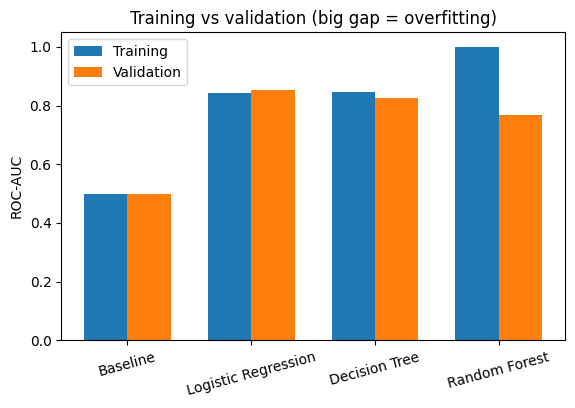

In [7]:
plt.figure(figsize=(6.5, 4))
plt.bar(table.index, table["Train ROC-AUC"], width=-0.35, align="edge", label="Training")
plt.bar(table.index, table["ROC-AUC"], width=0.35, align="edge", label="Validation")
plt.ylabel("ROC-AUC"); plt.title("Training vs validation (big gap = overfitting)"); plt.legend(); plt.xticks(rotation=15)
plt.show()

## 12. Why this model was selected

In [8]:
final_name = "Logistic Regression"
final_model = models[final_name]
p, proba = final_model.predict(X_test), get_proba(final_model, X_test)
print(f"Selected: {final_name}")
print(f"Test set -> Accuracy {accuracy_score(y_test, p):.3f} | Precision {precision_score(y_test, p):.3f} | "
      f"Recall {recall_score(y_test, p):.3f} | ROC-AUC {roc_auc_score(y_test, proba):.3f}")

Selected: Logistic Regression
Test set -> Accuracy 0.820 | Precision 0.726 | Recall 0.456 | ROC-AUC 0.841


**Logistic Regression is chosen** — not because it has the single highest validation accuracy (Decision Tree is 0.6 points higher on that), but because it:
1. has the **best overall ROC-AUC** (validation and cross-validation both agree),
2. shows **almost no overfitting**, unlike Random Forest,
3. is the **simplest and easiest to explain** to a marketing team, and
4. is **fast** to retrain whenever new customers need scoring.

The result holds up on the test set: ROC-AUC 0.841, close to the validation score, so nothing was overfit.
